# Plateau’s Problem for Catenoid

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from tqdm.notebook import trange
import k3d
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from external.preconditioning.model_architecture import GeneralNet
from external.preconditioning.optimizers import HandNGD 
## Point-sampler
from GINN.numerical_boundary import find_boundary_points_numerically_with_binsearch
from models.net_w_partials import NetWithPartials
from util.sample_utils import precompute_sample_grid

torch.manual_seed(0)


device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [25]:
from util.visualization.utils_mesh import get_mesh

# Parametric equations for the catenoid in polar coordinates
def catenoid_surface_polar(v, u, c=1.0):
    x = c * torch.cosh(v / c) * torch.cos(u)
    y = c * torch.cosh(v / c) * torch.sin(u)
    z = v
    return x, y, z

# Level set function for the catenoid
def catenoid_level_set(x, c=1.0):
    x1 = x[:, 0]
    y1 = x[:, 1]
    z1 = x[:, 2]
    
    # Level set equation derived from the catenoid's implicit equation
    return x1**2 + y1**2 - (c**2 * torch.cosh(z1 / c)**2)

# Bounds and number of samples
n = 1000
u = torch.linspace(-torch.pi, torch.pi, n, dtype=torch.float64)
# v_max = 0.3  # Adjust this to control the size of the catenoid
v_max = 1.0
c = 1.0
v = torch.linspace(-v_max, v_max, n, dtype=torch.float64)

# Generate boundary points for the upper and lower circles
v_constant_upper = torch.full_like(u, v_max, dtype=torch.float64)  # Upper boundary circle at v_max
v_constant_lower = torch.full_like(u, -v_max, dtype=torch.float64)  # Lower boundary circle at v_min
# u_constant = torch.full_like(v, 0, dtype=torch.float64)

# Compute points for the upper and lower circles
x_upper, y_upper, z_upper = catenoid_surface_polar(v_constant_upper, u, c)
x_lower, y_lower, z_lower = catenoid_surface_polar(v_constant_lower, u, c)
# x_side, y_side, z_side = catenoid_surface_polar(v, u_constant, c)

# Combine the points for both circles
pts_upper = torch.vstack([x_upper, y_upper, z_upper]).T
pts_lower = torch.vstack([x_lower, y_lower, z_lower]).T
# pts_side= torch.vstack([x_side, y_side, z_side]).T


# Concatenate the upper and lower boundary points
pts_boundary = torch.cat([pts_upper, pts_lower], dim=0)


# Generate the mesh using the level set function
verts, faces = get_mesh(
    lambda x: catenoid_level_set(x, c),  # Pass the level set with c=1.0
    N=128, 
    device=device,
    bbox_min=torch.tensor([-2, -2, -1.25], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 1.25], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()


Output()

In [30]:
# Generate random training points
model = GeneralNet(ks=[3, 32, 32, 1])
model = model.double()
# Generate random training points
num_pretrain_samples = 10000
bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)  # Assuming domain is [-1,1]^3
pts_pretrain = torch.rand(num_pretrain_samples, 3, dtype=torch.float64) * (bounds[:,1] - bounds[:,0]) + bounds[:,0]


def pretrain_loss(model, params, pts):
    inputs = pts.to(dtype=torch.float64)  # Ensure inputs are float64
    x, y = pts[:, 0], pts[:, 1]  # Extract x and y coordinates
    targets = x**2 + y**2 - 1  # Compute new target function
    preds = model(inputs).squeeze(1)  # Get model predictions
    return 0.5 * (preds - targets).square().mean()  # MSE loss

# Pretraining loop
pretrain_optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_pretrain_iters = 1000

for i in range(num_pretrain_iters):
    pretrain_optimizer.zero_grad()
    loss = pretrain_loss(model, model.params, pts_pretrain)
    loss.backward()
    pretrain_optimizer.step()
    
    if i % 100 == 0:
        print(f"Pretrain Iter {i}: Loss= {loss.item():.6f}")

print("Pretraining completed!")


Pretrain Iter 0: Loss= 0.104111
Pretrain Iter 100: Loss= 0.068229
Pretrain Iter 200: Loss= 0.005067
Pretrain Iter 300: Loss= 0.001186
Pretrain Iter 400: Loss= 0.000455
Pretrain Iter 500: Loss= 0.000215
Pretrain Iter 600: Loss= 0.000123
Pretrain Iter 700: Loss= 0.000083
Pretrain Iter 800: Loss= 0.000062
Pretrain Iter 900: Loss= 0.000049
Pretrain Iter 1000: Loss= 0.000040
Pretrain Iter 1100: Loss= 0.000035
Pretrain Iter 1200: Loss= 0.000031
Pretrain Iter 1300: Loss= 0.000027
Pretrain Iter 1400: Loss= 0.000025
Pretrain Iter 1500: Loss= 0.000023
Pretrain Iter 1600: Loss= 0.000021
Pretrain Iter 1700: Loss= 0.000019
Pretrain Iter 1800: Loss= 0.000018
Pretrain Iter 1900: Loss= 0.000017
Pretraining completed!


### Define the boundary rectangles

In [31]:
# pts_space = torch.rand([1000, 3], dtype=torch.float64)
# pts_space_fixed = torch.rand([1000, 3], dtype=torch.float64)
pts_space = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
pts_space_fixed = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
pts_eikonal = torch.cat((pts_space_fixed, pts_boundary))
pts_surface = pts_boundary


loss_weights = {"interface": 1.0, "eikonal": 0.001, "curvature": 1.0}
# loss_weights = {"interface": 1.0, "eikonal": 0.5, "curvature": 1.0}
# loss_weights = {"interface": 1.0, "eikonal": 0.01, "curvature": 1.0}




config = {
    "pts_boundary": pts_boundary,
    "pts_eikonal": pts_eikonal,
    "pts_space": pts_space,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
}

# model = GeneralNet(ks=[3, 32, 32, 1])
# model = GeneralNet(ks=[3, 50, 50, 1])
model = model.double()

### Point-sampler demo

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

### Main training loop

In [32]:
def sample_true_surface(n_samples, c=1.0):
    # Generate radial and angular coordinates
    r = torch.linspace(-v_max, v_max, n_samples, dtype=torch.float64)
    phi = torch.linspace(-torch.pi, torch.pi, 2*n_samples, dtype=torch.float64)
    
    # Create a grid of r and phi
    r, phi = torch.meshgrid(r, phi, indexing='ij')

    # Compute the x, y, z coordinates using the parametric equations
    x, y, z = catenoid_surface_polar(r.flatten(), phi.flatten(), c)
    points_on_surface = torch.vstack([x, y, z]).T

    return points_on_surface

def sample_model_surface_newton(model, init_points, n_iter=10, newton_clip=0.15, tol=1e-8):

    for _ in range(n_iter):
        init_points.requires_grad_(True)
        f_val = model(init_points)  # Evaluate function value
        
        # Compute gradient
        # grad_f = torch.autograd.grad(f_val.sum(), init_points, create_graph=True)[0]
        grad_f = model.vf_x(model.params, init_points).squeeze(1)

        # Avoid division by small gradients
        grad_norm_sq = torch.sum(grad_f**2, dim=1, keepdim=True)
        valid = grad_norm_sq.squeeze() > 1e-10
        step = torch.zeros_like(init_points)
        
        # Newton step: p_new = p_old - f(p) * grad_f / ||grad_f||^2
        step[valid] = (f_val[valid] / grad_norm_sq[valid]) * grad_f[valid]
        step = torch.clamp(step, -newton_clip, newton_clip)  # Clip updates

        init_points = init_points - step.detach()

        # Stop early if all points are close to zero level set
        if torch.max(torch.abs(f_val)) < tol:
            break

    # Filter valid points (close to zero level set)
    valid_mask = torch.abs(f_val) < tol
    valid_mask = valid_mask.squeeze(1)
    points_on_surface = init_points[valid_mask].detach()
    
    return points_on_surface

def sample_model_surface_binsearch(model):
    netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
    bounds = torch.tensor([[-2,2], [-2,2], [-2,2]], dtype=torch.float64)
    grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
            10000, bounds, equidistant=True)

    success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
        netp=netp, 
        z=torch.zeros([1,0], dtype=torch.float64),
        n_steps=10,
        x_grid=grid_find_surface, 
        x_grid_dist=grid_dist_find_surface, 
        level_set=0.0,
        nf_is_density=True,
        resolution=init_grid_resolution
        )
    if success:
        points_on_surface = p_surface.data
        points_on_surface = torch.cat((pts_boundary, points_on_surface))
    else:
        points_on_surface = pts_boundary
    # else:
    #     x = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    #     y = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    #     z = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
        
    #     xx, yy, zz = torch.meshgrid(x, y, z, indexing='ij')
    #     grid_points = torch.stack([xx.flatten(), yy.flatten(), zz.flatten()], dim=1)
        
    #     with torch.no_grad():
    #         values = model(grid_points).squeeze()
    #         mask = torch.isclose(values, torch.zeros_like(values), atol=1e-4)  # Adjust tolerance
    #         points_on_surface = grid_points[mask]
        
    return points_on_surface

def compute_distance(model, true_implicit, pts_surface_model, pts_surface_true):    

    # Refine model surface samples for exact error calculation
    pts_surface_model = sample_model_surface_newton(model, pts_surface_model)
    
    # Cut away points further away than the boundary points
    distances = torch.norm(pts_surface_model[:, :2], dim=1)    
    pts_surface_model = pts_surface_model[distances <= np.cosh(v_max)]

    # Compute the integral of squared values over both surfaces
    with torch.no_grad():
        d_model = model(pts_surface_true).squeeze().square().mean()
        d_true = true_implicit(pts_surface_model).squeeze().square().mean()
        distance = torch.sqrt(d_model + d_true).item()

    return distance

def chamfer_disc(model, pts_surface_true):    

    # Flow true points onto the surface
    pts_surface_model = sample_model_surface_newton(model, pts_surface_true)    
    dists = torch.cdist(pts_surface_model, pts_surface_true, p=2) ** 2  # Shape (M, N)
    # For each x in Q (model surface), find the closest y in P (true surface)
    min_dists, _ = dists.min(dim=1)  # Shape (M,)
    # Compute Chamfer divergence
    distance = min_dists.mean()

    return torch.sqrt(distance).item()

netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
pts_surface_true = sample_true_surface(64)
# pts_surface_true = sample_true_surface(512)
# pts_surface_model = sample_model_surface_binsearch(model.double())
# distance = compute_distance(model.double(), enneper_level_set, pts_surface_model, pts_surface_true)
distance = chamfer_disc(model, pts_surface_true)
print(f"Distance d(f_i, f_j): {distance}")



Distance d(f_i, f_j): 0.19119213712564678


In [37]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-3, -3, -1.5], dtype=torch.float64),
    bbox_max=torch.tensor([3, 3, 1.5], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(pts_surface_true.cpu().detach(), point_size=0.05)
fig.display()

Output()

In [414]:
import time

model = model.double()
params = model.params
loss_over_time = {}
distance_over_time = {}
chamfer_over_time = {}
bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)
# Gauss-Newton:
# optim = HandNGD(model, lr=1e-2, config=config)
optim = HandNGD(model, lr=0.1, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
# eikonal weight has to be small compared to h_laplace, see StabEik
start_time = time.time()
current_time = 0
for i in (pbar:=trange(10000)):
    if current_time > 1200:
        break
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    # loss_laplacian = 0.5*model.v_f_laplace(params, pts_space).squeeze(1).square().mean()

    if i == 500:
        loss_weights = {"interface": 1.0, "eikonal": 0.0, "curvature": 1.0}
        config["loss_weights"] = loss_weights
        optim.config = config

    pts_surface = sample_model_surface_binsearch(model)
    config["pts_surface"] = pts_surface
    optim.config = config
    
    loss_curvature = 0.5*model.v_f_mean_curvature(params, pts_surface).squeeze(1).square().mean()
       
    # loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["laplacian"] * loss_laplacian + loss_weights["curvature"] * loss_curvature
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["curvature"] * loss_curvature

    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_curvature
        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric.item()
        distance_over_time[current_time] = compute_distance(model.double(), catenoid_level_set, pts_surface, pts_surface_true)
        chamfer_over_time[current_time] = chamfer_disc(model, pts_surface_true)
        

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"curvature: {loss_curvature.item():.2e} "
                            # f"laplacian: {loss_laplacian.item():.2e} "
                            f"error: {chamfer_over_time[current_time]:.2e} "
                            f"{len(pts_surface)}"
                            )
    optim.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [112]:
import time

model = model.double()
params = model.params
loss_over_iters = {}
distance_over_iters = {}
chamfer_over_iters = {}
# Gauss-Newton:
# optim = HandNGD(model, lr=1e-1, config=config)
# Adam:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
# eikonal weight has to be small compared to h_laplace, see StabEik

for i in (pbar:=trange(10000)):
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    # loss_laplacian = 0.5*model.v_f_laplace(params, pts_space).squeeze(1).square().mean()

    if i == 500:
        loss_weights = {"interface": 1.0, "eikonal": 0.0, "curvature": 1.0}
        config["loss_weights"] = loss_weights
        optim.config = config

    pts_surface = sample_model_surface_binsearch(model)
    config["pts_surface"] = pts_surface
    optim.config = config
    
    loss_curvature = 0.5*model.v_f_mean_curvature(params, pts_surface).squeeze(1).square().mean()
       
    # loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["laplacian"] * loss_laplacian + loss_weights["curvature"] * loss_curvature
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["curvature"] * loss_curvature

    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_curvature
        distance_over_iters[i] = compute_distance(model.double(), catenoid_level_set, pts_surface, pts_surface_true)
        chamfer_over_iters[i] = chamfer_disc(model, pts_surface_true)
        

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"curvature: {loss_curvature.item():.2e} "
                            f"error: {distance_over_iters[i]:.2e} "
                            f"{len(pts_surface)}"
                            )
        loss_over_iters[i] = loss_metric.item()
    optim.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

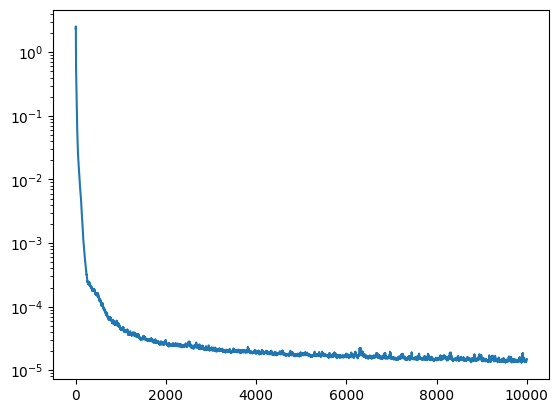

In [136]:
plt.plot(distance_over_iters.keys(), distance_over_iters.values())
plt.semilogy()
# plt.savefig("error_catenoid.png")
plt.show()

In [ ]:
plt.plot(chamfer_over_iters.keys(), chamfer_over_iters.values())
plt.semilogy()
# plt.savefig("error_catenoid.png")
plt.show()

In [445]:
loss_file = "dist_over_time_catenoid_lbfgs.pth"
torch.save(distance_over_time, loss_file)
print(f"Loss saved to {loss_file}")

Loss saved to dist_over_time_catenoid_lbfgs.pth


### Visualize the result

In [432]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -1.25], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 1.25], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(pts_surface_true.cpu().detach(), point_size=0.05)

fig.display()

Output()

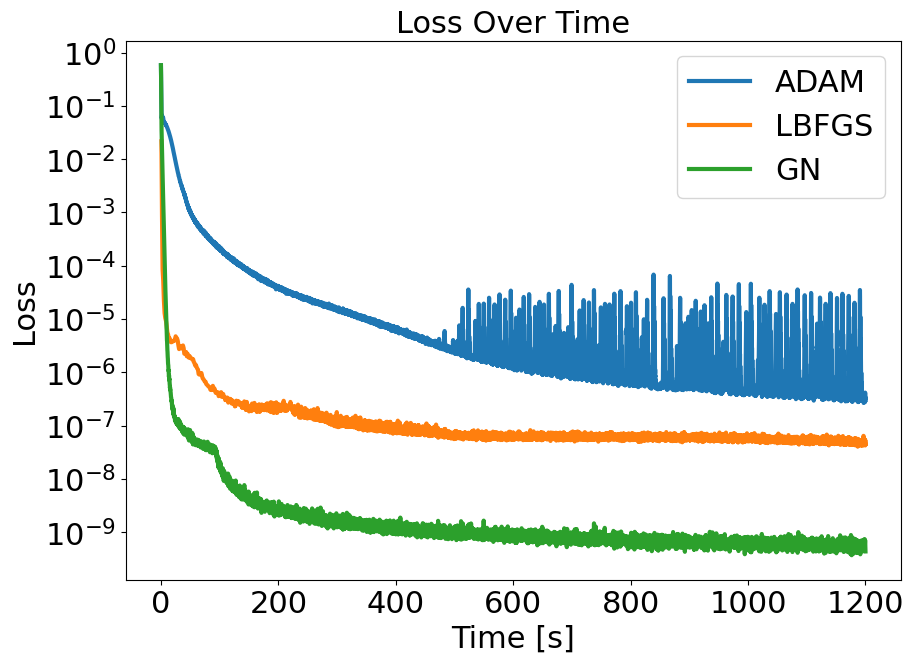

loss_over_time_catenoid.png


In [69]:
import torch
import matplotlib.pyplot as plt

# Load the loss data
loss_over_iters_adam = torch.load("loss_over_time_catenoid_adam.pth")
loss_over_iters_gn = torch.load("loss_over_time_catenoid_gn.pth")
loss_over_iters_lbfgs = torch.load("loss_over_time_catenoid_lbfgs.pth")

# Extract keys (iterations) and values (losses)
adam_iterations = list(loss_over_iters_adam.keys())
adam_values = list(loss_over_iters_adam.values())

gn_iterations = list(loss_over_iters_gn.keys())
gn_values = list(loss_over_iters_gn.values())

lbfgs_iterations = list(loss_over_iters_lbfgs.keys())
lbfgs_values = list(loss_over_iters_lbfgs.values())

plt.figure(figsize=(10, 7))

plt.plot(adam_iterations, adam_values, label="ADAM", linewidth=3)
plt.plot(lbfgs_iterations, lbfgs_values, label="LBFGS", linewidth=3)
plt.plot(gn_iterations, gn_values, label="GN", linewidth=3)



plt.semilogy()  # Use logarithmic scale for the y-axis
plt.xlabel("Time [s]", fontsize=22)
plt.ylabel("Loss", fontsize=22)
plt.title("Loss Over Time", fontsize=22)
plt.legend(fontsize=22, loc="upper right")
plt.xticks(fontsize=22)
plt.yticks(np.logspace(start=-9, stop=0, num=10), fontsize=22)
plt.savefig("a_output.png")
plt.show()
print("loss_over_time_catenoid.png")




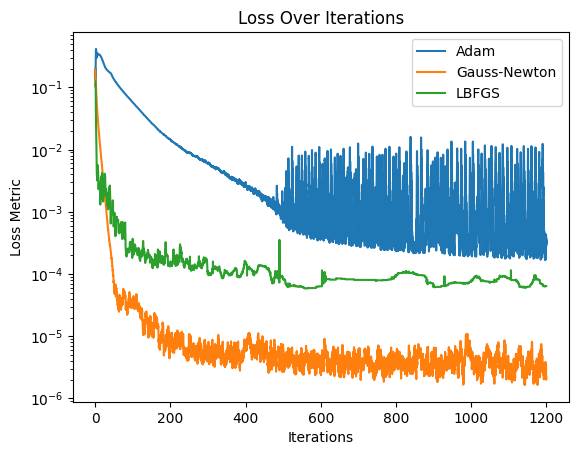

In [5]:
import torch
import matplotlib.pyplot as plt

# Load the loss data
loss_over_iters_adam = torch.load("chamf_over_time_catenoid_adam.pth")
loss_over_iters_gn = torch.load("chamf_over_time_catenoid_gn.pth")
loss_over_iters_lbfgs = torch.load("chamf_over_time_catenoid_lbfgs.pth")

# Extract keys (iterations) and values (losses)
adam_iterations = list(loss_over_iters_adam.keys())
adam_values = list(loss_over_iters_adam.values())

gn_iterations = list(loss_over_iters_gn.keys())
gn_values = list(loss_over_iters_gn.values())

lbfgs_iterations = list(loss_over_iters_lbfgs.keys())
lbfgs_values = list(loss_over_iters_lbfgs.values())


plt.plot(adam_iterations, adam_values, label="Adam")
plt.plot(gn_iterations, gn_values, label="Gauss-Newton")
plt.plot(lbfgs_iterations, lbfgs_values, label="LBFGS")


plt.semilogy()  # Use logarithmic scale for the y-axis
plt.xlabel("Iterations")
plt.ylabel("Loss Metric")
plt.title("Loss Over Iterations")
plt.legend()
# plt.savefig("loss_comparison_moving.png")
plt.show()




In [291]:
a = np.array(list(loss_over_iters_lbfgs.values())[:10000])
a.min()

0.0004193791885183856

In [293]:
a = np.array(list(loss_over_iters_lbfgs.values()))
a.min()

0.00040901559406197966

In [129]:
a = pts_boundary[0]

In [439]:
pts_surface = sample_model_surface_binsearch(model.double())

  0%|          | 0/10000 [00:00<?, ?it/s]

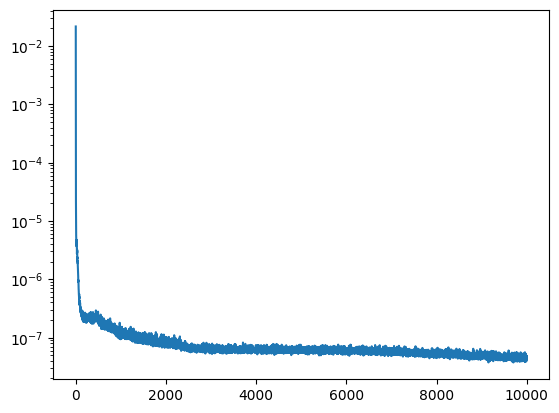

In [440]:
# import time
# import torch
# from tqdm import trange
# import matplotlib.pyplot as plt

pts_surface = sample_model_surface_binsearch(model.double())
params = model.params
loss_over_time = {}
distance_over_time = {}
chamfer_over_time = {}
loss_cache = {}
bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)

# LBFGS Optimizer
# optim = torch.optim.LBFGS(model.parameters(), lr=1e-3, max_iter=20, tolerance_grad=1e-7, tolerance_change=1e-9)
optim = torch.optim.LBFGS(model.parameters())


start_time = time.time()
current_time = 0
for i in (pbar:=trange(10000)):
    if current_time > 1200:
        break
    if i == 500:
        loss_weights = {"interface": 1.0, "eikonal": 0.0, "curvature": 1.0}
        config["loss_weights"] = loss_weights
        optim.config = config    
    
    def closure():
        optim.zero_grad()
        
        ## 1) Interface at boundaries
        loss_interface  = 0.5 * model.f(params, pts_boundary).square().mean()

        ## 2) Eikonal at boundaries
        loss_eikonal  = 0.5 * (model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

        try:
            pts_surface = sample_model_surface_binsearch(model)
        except:
            pass
        config["pts_surface"] = pts_surface
        optim.config = config
        
        ## 3) Curvature loss
        loss_curvature = 0.5 * model.v_f_mean_curvature(params, pts_surface).squeeze(1).square().mean()
        
        loss = (
            loss_weights["interface"] * loss_interface +
            loss_weights["eikonal"] * loss_eikonal +
            loss_weights["curvature"] * loss_curvature
        )

        loss_cache["interface"] = loss_interface.item()
        loss_cache["eikonal"] = loss_eikonal.item()
        loss_cache["curvature"] = loss_curvature.item()
        loss_cache["total"] = loss.item()
        loss_cache["pts_surface"] = pts_surface
        
        loss.backward()
        return loss
    
    loss = optim.step(closure)
    
    with torch.no_grad():
       
        loss_metric = loss_cache["interface"] + loss_cache["curvature"]
        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric
        distance_over_time[current_time] = compute_distance(model.double(), catenoid_level_set, pts_surface, pts_surface_true)
        chamfer_over_time[current_time] = chamfer_disc(model, pts_surface_true)
        
        # pbar.set_description(f"interface: {loss_interface.item():.2e} "
        #                      f"eikonal: {loss_eikonal.item():.2e} "
        #                      f"curvature: {loss_curvature.item():.2e} "
        #                      f"error: {chamfer_over_iters[i]:.2e} "
        #                      f"{len(pts_surface)}"
        #                     )
        pbar.set_description(f"interface: {loss_cache['interface']:.2e} "
                             f"eikonal: {loss_cache['eikonal']:.2e} "
                             f"curvature: {loss_cache['curvature']:.2e} "
                             f"error: {chamfer_over_time[current_time]:.2e} "
                             f"{len(loss_cache['pts_surface'])}"
                            )

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()


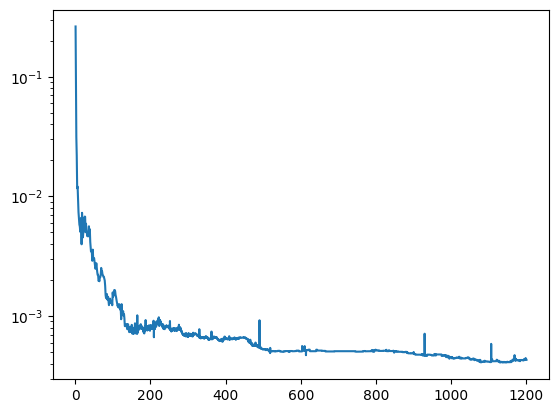

In [442]:
plt.plot(distance_over_time.keys(), distance_over_time.values())
plt.semilogy()
plt.show()


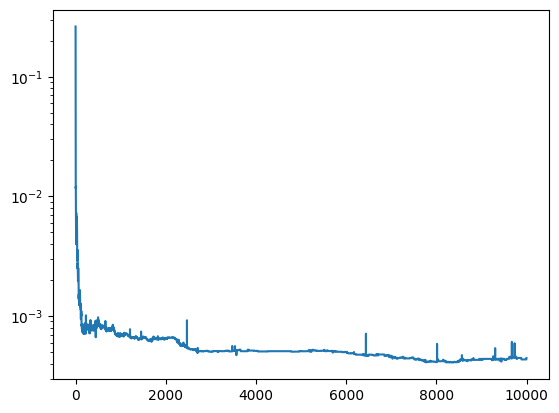

In [334]:

plt.plot(distance_over_iters.keys(), distance_over_iters.values())
plt.semilogy()
plt.show()
